#  Model Training Notebook

**Description**

This notebook includes training, test, and validation set creation and model training step. The model that is used in this project is U-Net with ResNet-50 backbone. The Pre-trained model is `ResNet50_Weights.SENTINEL2_ALL_MOCO` which is available in torchgeo library.

**Input folder(s)/file(s)**

2 files
- Public Urban Green Spaces (PUGS) ground truth (`dresden_pugs_gt.geojson`)
- Sentinel-2 image stack with PUGS OSM binary mask and SDT (clipped to Dresden boundary) (`stacked_sentinel2_dresden_clipped.geotiff`)

**Output folder(s)/file(s)**

3 folders and 2 files
- Output folder for image tiles of training set (`../data/processed/tiles/train`)
- Output folder for image tiles of test set (`../data/processed/tiles/test`)
- Output folder for image tiles of validation set (`../data/processed/tiles/val`)
- The best model checkpoint (example: `epoch=47-val_loss=0.18.ckpt`)
- Metrics file (CSV file) (`metrics.csv`)
- Hyperparmeters log file (`hparams.yaml`)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first:
- 1_data_acquisition_osm.ipynb
- 1_data_acquisition_satellite_image.ipynb
- 2_data_processing_osm.ipynb
- 2_data_processing_ground_truth.ipynb
- 3_data_processing_satellite_image.ipynb
- 5_ground_truth_creation.ipynb

    **Note:** It does not require user to run `4_ground_truth_exploration.ipynb` notebook. The exploration notebook is created for understanding how each ground truth dataset complement each other and help author decide on which datasets will be used to create a final ground truth dataset.

    In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

**Remarks**

The output shown in the notebook is run from this model experiment.

- **Input**: Sentinel-2 image and PUGS binary mask derived from OSM (input channels = 14 channels)
- **Loss function**: Jaccard loss

More detail about model experiment setup can be found in [Model experiment setup](../models/README.md#model-experiment-setup)

# 1. Import libraries and load config

It can take up to 5-6 mins to complete this section.

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
import torch
import yaml
from torchgeo.transforms import AugmentationSequential
from tqdm import tqdm
import kornia.augmentation as K
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from torchgeo.models import ResNet50_Weights
from torch.utils.data import DataLoader
from pugs_detection.raster import create_image_tiles
from pugs_detection.modeling.model import modify_first_layer
from pugs_detection.plots import plot_image_tiles, visualize_from_torchgeo_dataloader
from pugs_detection.modeling.segmentation_task import CustomSegmentationTask
from pugs_detection.utils import set_all_seeds
from pugs_detection.dataset import create_dataset_split

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You will likely lose important projection information when converting to a PROJ string from another format.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired.*",
    category=UserWarning,
)

In [4]:
# Load config
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# 2. Set seed to make it reproducible

In [5]:
# Set seeds for reproducibility
seed = config["general"]["seed"]
set_all_seeds(seed)

Seed set to 42


In [6]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

# 3. Set variables

In [7]:
train_index_list = config["data"]["train_index_list"]
val_index_list = config["data"]["val_index_list"]
test_index_list = config["data"]["test_index_list"]

output_folder_path = config["paths"]["tiles_folder_path"]
image_path = config["paths"]["clipped_image_path"]

# Define paths for pre-split tiles
train_image_path = config["paths"]["train_image_path"]
val_image_path = config["paths"]["val_image_path"]
test_image_path = config["paths"]["test_image_path"]
# Vector data path
label_path = config["paths"]["gt_vector_path"]

band_list = config["data"]["band_list"]
num_channels = len(band_list)

crs = config["data"]["crs"]

# 4. Create image tiles for training, validation, and test set

Manually specify the tiles to training, validation, and test set

In [8]:
all_tiles_list = create_image_tiles(
    output_folder_path, image_path, train_index_list, val_index_list, test_index_list
)

Image bounds width: 27110.0 height: 22640.0
Tile dimensions width: 5422.0 height: 4528.0
Skipping tile 1: only 0.0% valid data
Tile 2 saved to train folder (44.1% valid data)
Tile 3 saved to train folder (85.5% valid data)
Skipping tile 4: only 7.1% valid data
Skipping tile 5: only 0.0% valid data
Skipping tile 6: only 13.1% valid data
Tile 7 saved to val folder (93.7% valid data)
Tile 8 saved to test folder (96.0% valid data)
Tile 9 saved to train folder (36.7% valid data)
Skipping tile 10: only 0.8% valid data
Tile 11 saved to train folder (59.6% valid data)
Tile 12 saved to train folder (100.0% valid data)
Tile 13 saved to train folder (100.0% valid data)
Tile 14 saved to test folder (99.0% valid data)
Tile 15 saved to train folder (54.1% valid data)
Tile 16 saved to train folder (77.7% valid data)
Tile 17 saved to val folder (100.0% valid data)
Tile 18 saved to train folder (99.7% valid data)
Tile 19 saved to val folder (92.5% valid data)
Tile 20 saved to train folder (35.7% valid 

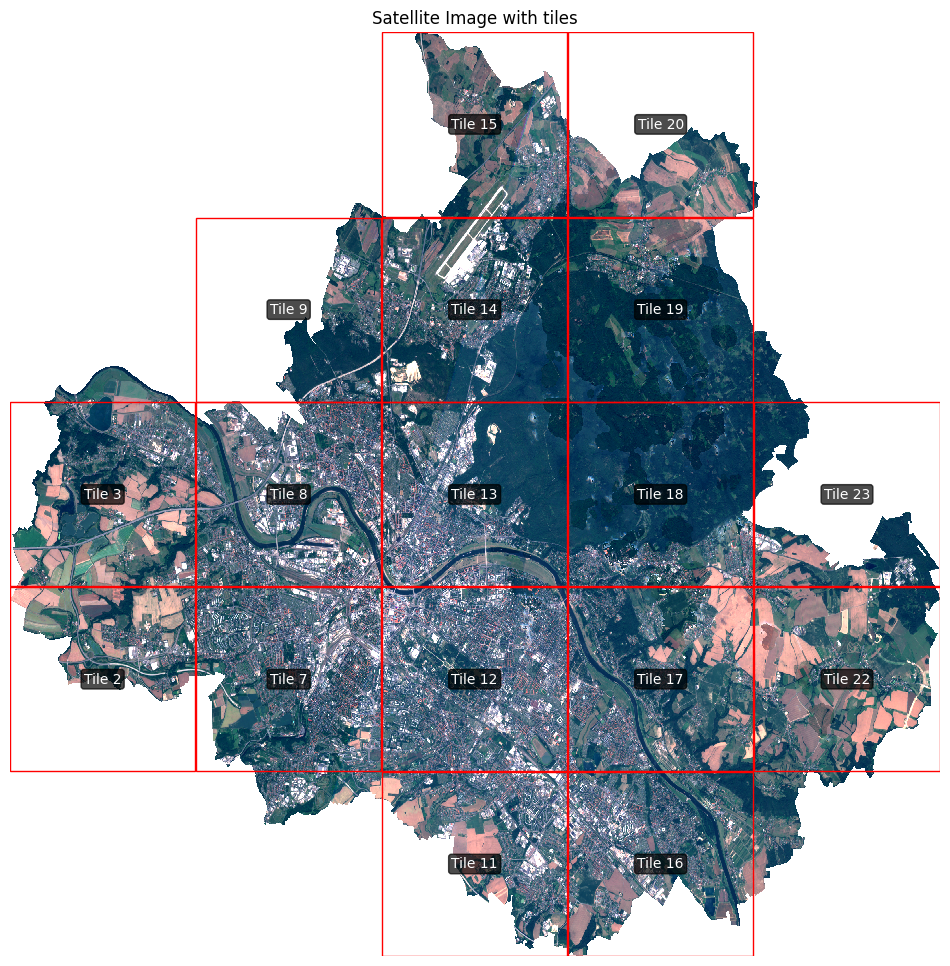

In [9]:
plot_image_tiles(image_path, all_tiles_list)

# 5. Creating image patches

In [10]:
# Create specific augmentation transforms
h_flip_transform = AugmentationSequential(
    K.RandomHorizontalFlip(p=1.0), data_keys=["image", "mask"]
)

v_flip_transform = AugmentationSequential(
    K.RandomVerticalFlip(p=1.0), data_keys=["image", "mask"]
)

rotation_transform = AugmentationSequential(
    K.RandomRotation(degrees=45, p=1.0, align_corners=True), data_keys=["image", "mask"]
)

In [11]:
# Create list of specific transforms
transform_list = [h_flip_transform, v_flip_transform, rotation_transform]

## Create training dataset

In [12]:
# Create the filtered datasets
train_dataset = create_dataset_split(
    train_image_path, label_path, crs, band_list, "train", transform_list, seed
)

Seed set to 42
Filtering patches for train: 100%|██████████| 132/132 [01:10<00:00,  1.86patch/s]

Found 123 valid patches out of 132 total patches


In [13]:
print(len(train_dataset))

492


In [14]:
if config["general"]["os"] == "linux":
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["model"]["batch_size"],
        shuffle=True,
        collate_fn=stack_samples,
        num_workers=config["model"]["training_num_workers"],
        persistent_workers=True
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["model"]["batch_size"],
        shuffle=True,
        collate_fn=stack_samples,
    )

In [15]:
len(train_loader)

31

Seed set to 42


Sample 0:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.02


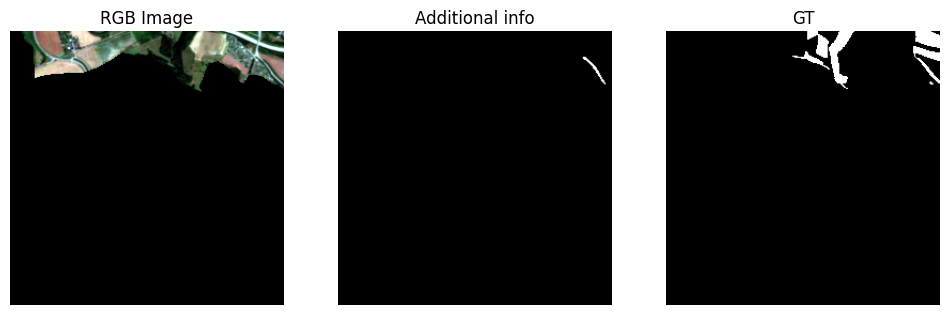

Sample 1:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.03


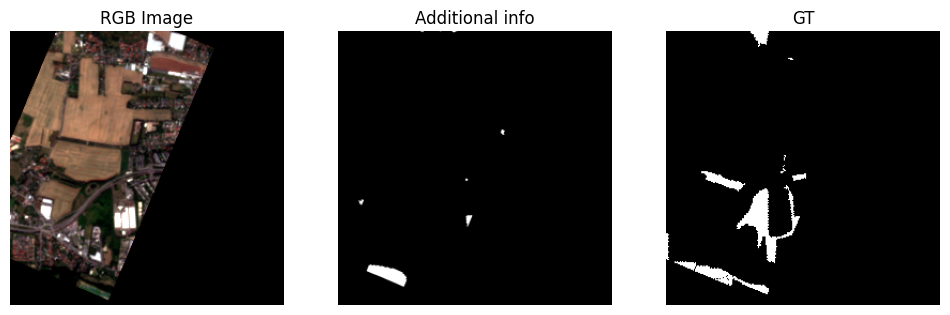

Sample 2:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.08


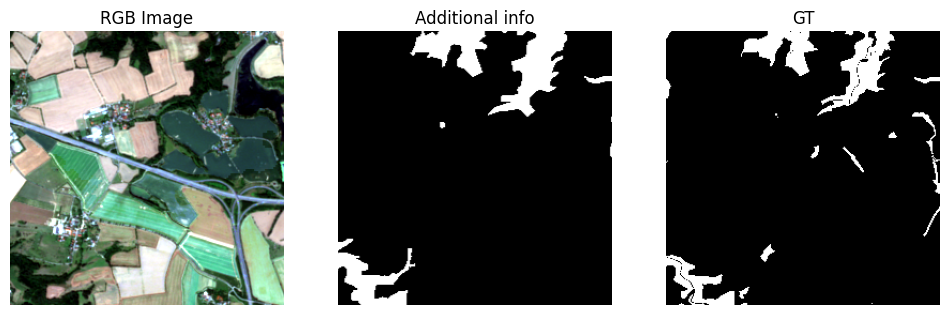

Sample 3:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.12


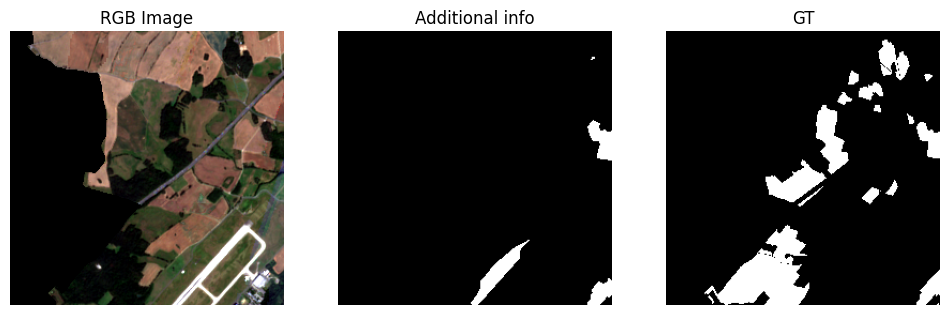

Sample 4:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.30


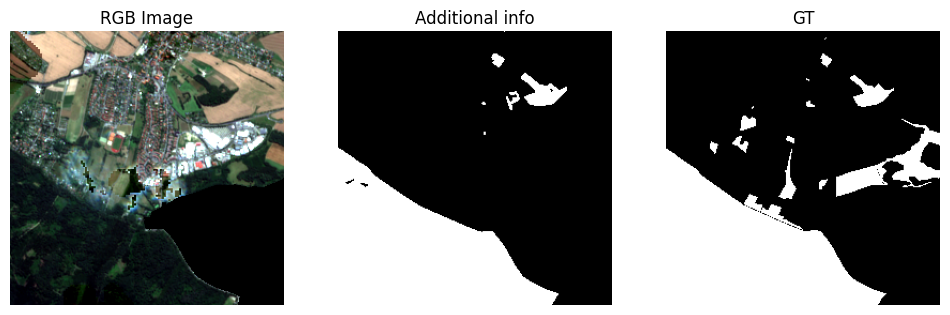

In [16]:
if num_channels > 13:
    visualize_from_torchgeo_dataloader(train_loader, 5, "additional", [13])
else:
    visualize_from_torchgeo_dataloader(train_loader, 5, "original")

## Create validation dataset

Set transform_sequence to None by default or optional params

In [17]:
val_dataset = create_dataset_split(
    val_image_path, label_path, crs, band_list, "validation", None, seed
)

Seed set to 42


Using all 36 patches for validation set


In [18]:
if config["general"]["os"] == "linux":
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["model"]["batch_size"],
        collate_fn=stack_samples,
        num_workers=config["model"]["validation_num_workers"],
        persistent_workers=True
    )
else:
    val_loader = DataLoader(
        val_dataset, batch_size=config["model"]["batch_size"], collate_fn=stack_samples
    )

Seed set to 42


Sample 0:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.11


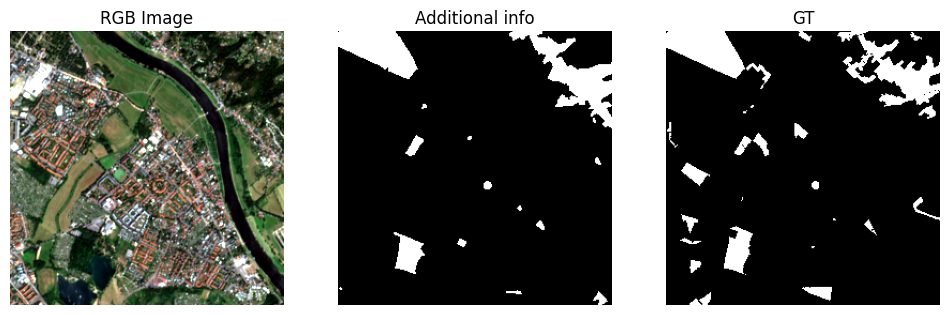

Sample 1:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.18


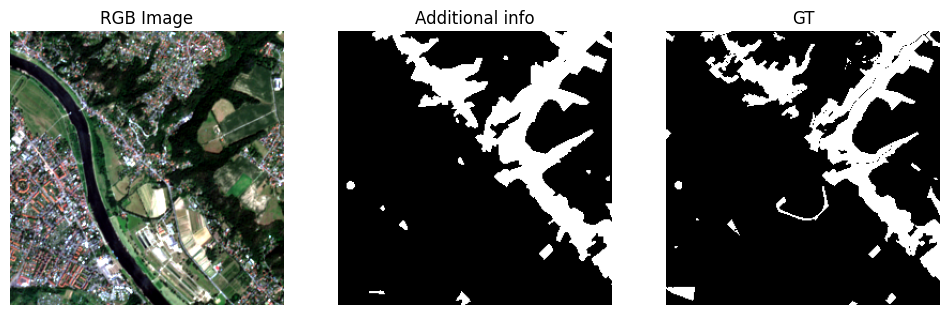

Sample 2:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.21


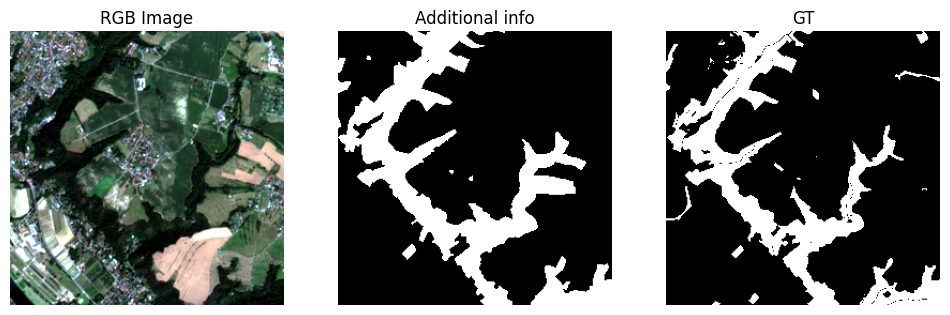

In [19]:
if num_channels > 13:
    visualize_from_torchgeo_dataloader(val_loader, 3, "additional", [13])
else:
    visualize_from_torchgeo_dataloader(val_loader, 3, "original")

## Create test dataset

Set transform_sequence to None by default or optional params

In [20]:
test_dataset = create_dataset_split(
    test_image_path, label_path, crs, band_list, "test", None, seed
)

Seed set to 42


Using all 36 patches for test set


In [21]:
if config["general"]["os"] == "linux":
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["model"]["batch_size"],
        collate_fn=stack_samples,
        num_workers=config["model"]["test_num_workers"],
        persistent_workers=True
    )
else:
    test_loader = DataLoader(
        test_dataset, batch_size=config["model"]["batch_size"], collate_fn=stack_samples
    )

In [22]:
len(test_loader)

3

Seed set to 42


Sample 0:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.39


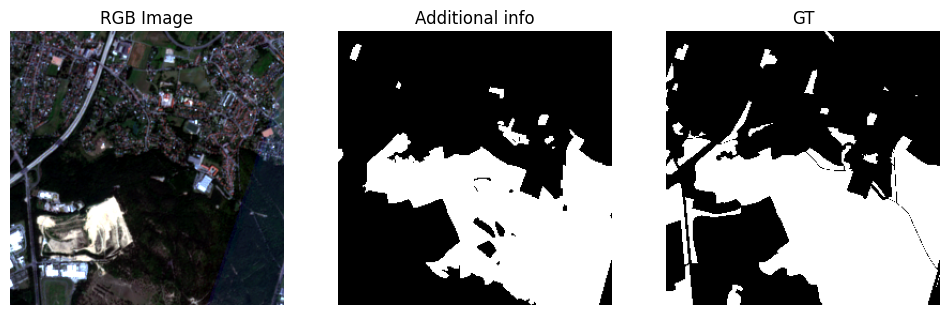

Sample 1:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.49


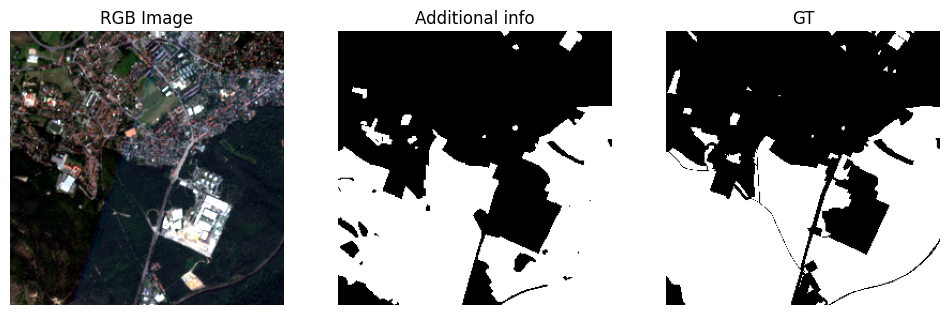

Sample 2:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.71


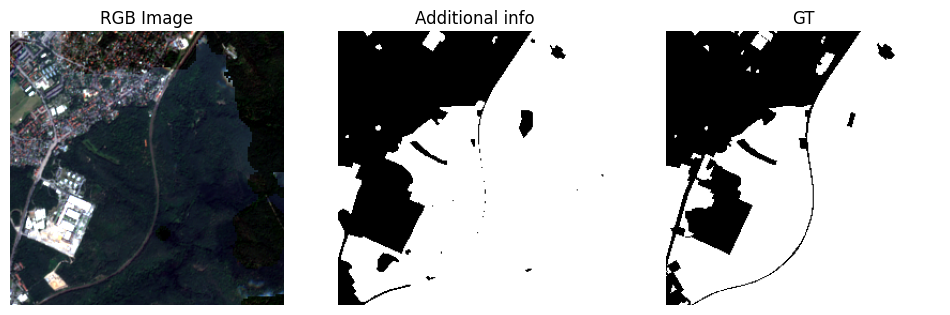

In [23]:
if num_channels > 13:
    visualize_from_torchgeo_dataloader(test_loader, 3, "additional", [13])
else:
    visualize_from_torchgeo_dataloader(test_loader, 3, "original")

# 6. Create and train model

In [24]:
if config["model"]["weight"] == "SENTINEL2_ALL_MOCO":
    weight = ResNet50_Weights.SENTINEL2_ALL_MOCO
else:
    # there is other weights available in TorchGeo library as well, but for now
    # using only the SENTINEL2_ALL_MOCO
    weight = ResNet50_Weights.SENTINEL2_ALL_MOCO

## Define Model

In [25]:
if num_channels > 13:
    task = CustomSegmentationTask(
        loss=config["model"]["loss_func"],
        model=config["model"]["architecture"],
        backbone=config["model"]["backbone"],
        weights=weight,
        in_channels=13,
        num_classes=1,
        lr=config["model"]["learning_rate"],
        patience=5,
    )

    task = modify_first_layer(task, in_channels=num_channels)
else:
    task = CustomSegmentationTask(
        loss=config["model"]["loss_func"],
        model=config["model"]["architecture"],
        backbone=config["model"]["backbone"],
        weights=weight,
        in_channels=num_channels,
        num_classes=1,
        lr=config["model"]["learning_rate"],
        patience=5,
    )

CustomSegmentationTask(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(14, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (re

## Training

In [26]:
checkpoint_callback = ModelCheckpoint(
    filename="{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    save_top_k=1,  # Save checkpoint with the best validation loss
)

In [27]:
early_stopping = EarlyStopping(monitor="val_loss", patience=config["model"]["patience"])

In [28]:
logger = CSVLogger(
    config["paths"]["logger_path"], name=config["paths"]["checkpoint_folder"]
)

In [29]:
trainer = Trainer(
    max_epochs=config["model"]["epochs"],
    deterministic=True,
    accelerator=config["model"]["accelerator"],
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [30]:
trainer.fit(model=task, train_dataloaders=train_loader, val_dataloaders=val_loader)

You are using a CUDA device ('NVIDIA RTX A500 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | Unet             | 32.6 M | train
1 | criterion     | JaccardLoss      | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollection | 0      | train
4 | test_metrics  | MetricCollection | 0      | train
-----------------------------------------------------------
32.6 M    Trainable params
0         Non-trainable params
32.6 M    Total params
130.222   Total estimated model params size (MB)
233       Module

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
